## Empleo de Algoritmos Clásicos de Machine Learning en Imágenes

In [1]:
!pip install scikit-learn
!pip install pandas

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C


  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [16]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Las imagenes son de tamaño 28x28.
# Pero las imágenes ya vienen desdobladas en vectores (28x28=784)
# Son 70k imágenes

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")
X = X[:1000]
y = y[:1000]

print(f"Forma reducida de los datos: {X.shape}")
print(f"Estructura reducida de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)
Forma reducida de los datos: (1000, 784)
Estructura reducida de las etiquetas: (1000,)


Etiqueta de la imagen: 9


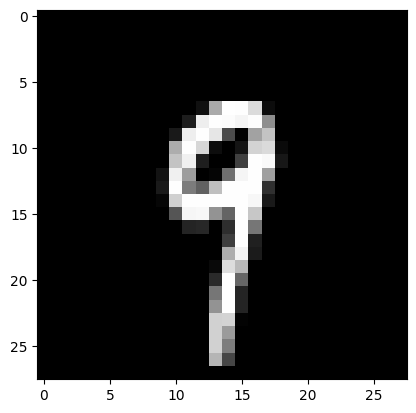

In [17]:
# Por ejemplo, se muestra la imagen 1:

imagen = X[600].reshape(28,28)
etiqueta = y[600]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.show()

In [18]:
# Se seleccionan los grupos de imagenes y etiquetas para el entrenamiento
# y las pruebas. No se debe probar con el mismo grupo de entrenamiento (sesgos).
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=5)

In [19]:
# Tomo sólo un grupo de datos. Si usamos todos tardará tiempo considerable 
# en el entrenamiento y predicción

X_train = X_train
y_train = y_train

X_test = X_test
y_test = y_test

In [20]:
len(X_train)

800

Entrenando SVM...
SVM - Accuracy: 0.8300, Precision: 0.8288, Recall: 0.8300, F1 Score: 0.8276


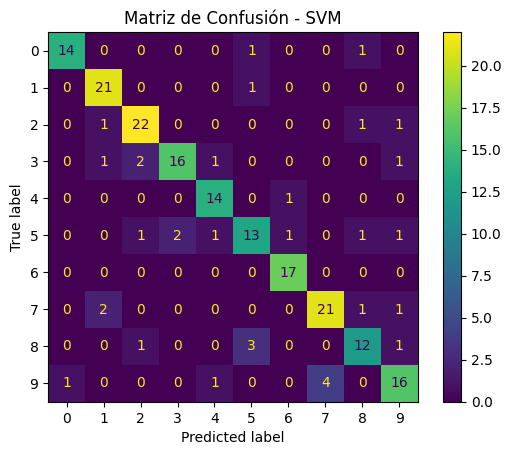

Entrenando KNN...
KNN - Accuracy: 0.8250, Precision: 0.8418, Recall: 0.8250, F1 Score: 0.8249


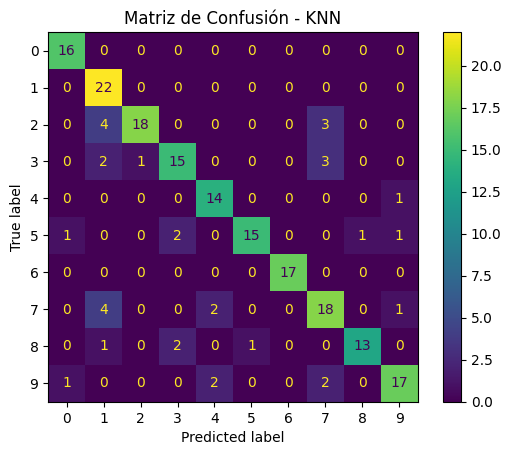

Entrenando Random Forest...
Random Forest - Accuracy: 0.8900, Precision: 0.8944, Recall: 0.8900, F1 Score: 0.8893


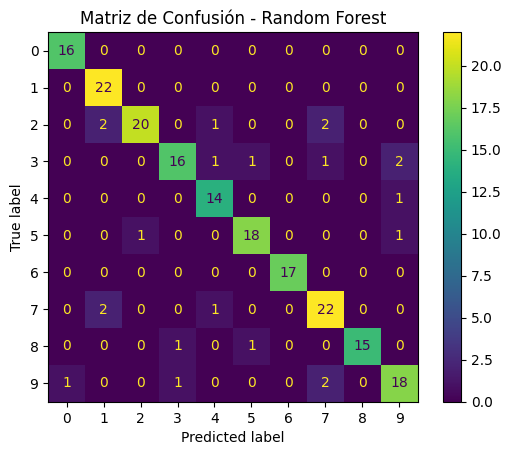

Entrenando Gradient Boosting...
Gradient Boosting - Accuracy: 0.8500, Precision: 0.8530, Recall: 0.8500, F1 Score: 0.8498


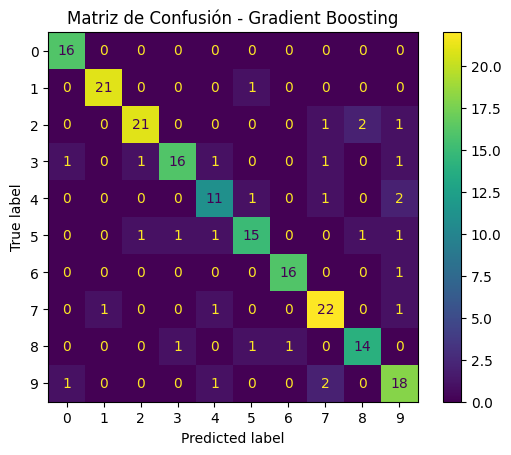

In [21]:
# Uso de máquinas de soporte vectorial (SVM) para clasificación

from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

modelos = {
    "SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=5)
}

resultados = {}
for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    resultados[nombre] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }
    
    print(f"{nombre} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 Score: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot()
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.show()

In [22]:
mejor_modelo = max(resultados, key=lambda x: resultados[x]["f1_score"])
print(f"\nEl mejor modelo fue: {mejor_modelo}")


El mejor modelo fue: Random Forest


In [23]:
def procesar_imagen(ruta):
    img = cv2.imread(ruta)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Preprocesamiento
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Encontrar contornos
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    digitos = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        if w > 10 and h > 10:
            digit = thresh[y:y+h, x:x+w]
            digitos.append((x, digit, (x,y,w,h)))

    # Ordenar de izquierda a derecha
    digitos = sorted(digitos, key=lambda x: x[0])

    resultados = []

    for _, d, (x,y,w,h) in digitos:
        d = cv2.resize(d, (28,28))
        d = cv2.bitwise_not(d)  # invertir colores
        d = d / 255.0
        d = d.reshape(1, -1)

        pred = modelo_final.predict(d)
        resultados.append((pred[0], (x,y,w,h)))

    # Dibujar resultados
    for valor, (x,y,w,h) in resultados:
        cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(img, str(valor), (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    return img, [r[0] for r in resultados]

# =========================================
# PROBAR CON IMÁGENES
# =========================================
imagenes = ["img/numeros_1.png", "img/numeros_2.png", "img/numeros_3.png"]

for ruta in imagenes:
    print(f"\nProcesando {ruta}...")

    img_resultado, digitos = procesar_imagen(ruta)

    print("Dígitos detectados:", digitos)

    cv2.imshow("Resultado", img_resultado)
    cv2.waitKey(0)

cv2.destroyAllWindows()


Procesando img/numeros_1.png...


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
# KNN, Random Forest y Gradient Boosting
# Investigar hiperparámetros principales, casos de uso.
# Calcular métricas y comparar todos incluyendo SVM
# ¿Cuál fue el mejor?
# INTENTAR: Entrenar y probar con los conjuntos de datos completos con 
# el mejor algoritmo